# Skin Disease 0.95 Target - Ensemble Attention Notebook

- Model A: `swin_v2_t` (Transformer attention)
- Model B: `efficientnet_v2_s` (strong CNN)
- 5-fold stratified CV, TTA, multi-model ensembling
- Auto path adaptation (local + platform)
- Every run creates a new timestamp folder under `runs/`


In [1]:
import copy
import gc
import json
import os
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from torchvision import models
from torchvision.transforms import v2

print('torch', torch.__version__)


torch 2.10.0


In [2]:
# =========================
# Config / paths
# =========================
LOCAL_BASE = Path('/Users/songling/Desktop/Skin Disease Classification')
PLATFORM_BASE = Path('dataset/public')

if PLATFORM_BASE.exists():
    MODE = 'platform'
    BASE_DIR = PLATFORM_BASE
    OUTPUT_DIR = Path('working')
elif LOCAL_BASE.exists():
    MODE = 'local'
    BASE_DIR = LOCAL_BASE
    OUTPUT_DIR = BASE_DIR
else:
    raise FileNotFoundError('Cannot find dataset path')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR = OUTPUT_DIR / 'runs'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
run_name = datetime.now().strftime('run_95_%Y%m%d_%H%M%S')
run_dir = RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=False)

TRAIN_CSV = BASE_DIR / 'train.csv'
TEST_CSV = BASE_DIR / 'test.csv'
TRAIN_IMG_DIR = BASE_DIR / 'train'
TEST_IMG_DIR = BASE_DIR / 'test'

CLASS_NAMES = ['acne', 'eksim', 'herpes', 'panu', 'rosacea']
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label = {i: c for c, i in label2idx.items()}

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
N_SPLITS = 5
EPOCHS = 14
HEAD_EPOCHS = 2
LR_HEAD = 1e-3
LR_FINE = 2e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP = 4
LABEL_SMOOTHING = 0.05

# Ensemble weights: attention model + CNN model
MODELS_TO_TRAIN = [
    {'name': 'swin_v2_t', 'weight': 0.55},
    {'name': 'efficientnet_v2_s', 'weight': 0.45},
]

NUM_WORKERS = 0 if MODE == 'local' else 2
PERSISTENT_WORKERS = NUM_WORKERS > 0

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

PIN_MEMORY = (device.type == 'cuda')
USE_AMP = (device.type == 'cuda')

print('MODE      :', MODE)
print('BASE_DIR  :', BASE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('RUN_DIR   :', run_dir)
print('DEVICE    :', device)


MODE      : local
BASE_DIR  : /Users/songling/Desktop/Skin Disease Classification
OUTPUT_DIR: /Users/songling/Desktop/Skin Disease Classification
RUN_DIR   : /Users/songling/Desktop/Skin Disease Classification/runs/run_95_20260220_163113
DEVICE    : mps


In [3]:
# =========================
# Data / transforms
# =========================
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

assert set(train_df['disease'].unique()) == set(CLASS_NAMES), 'Class mismatch'
assert len(test_df) == 180, f'Test rows should be 180, got {len(test_df)}'

train_df['label'] = train_df['disease'].map(label2idx)

def make_class_weights(df):
    counts = df['label'].value_counts().sort_index().values
    weights = len(df) / (len(CLASS_NAMES) * counts)
    return torch.tensor(weights, dtype=torch.float32)

class AddGaussianNoise(nn.Module):
    def __init__(self, std=0.02, p=0.25):
        super().__init__()
        self.std = std
        self.p = p

    def forward(self, x):
        if torch.rand(1).item() < self.p:
            x = torch.clamp(x + torch.randn_like(x) * self.std, 0.0, 1.0)
        return x

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tfms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.15),
    v2.RandomRotation(20),
    v2.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    v2.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.12, hue=0.03),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    AddGaussianNoise(std=0.02, p=0.25),
    v2.Normalize(MEAN, STD),
])

valid_tfms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(MEAN, STD),
])

class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row['filename']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        if self.is_test:
            return img, int(row['id'])
        return img, int(row['label'])


def build_loader(ds, shuffle=False):
    kwargs = dict(batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    if PERSISTENT_WORKERS:
        kwargs['persistent_workers'] = True
    return DataLoader(ds, **kwargs)


In [4]:
# =========================
# Models / train helpers
# =========================
def build_model(model_name):
    if model_name == 'swin_v2_t':
        m = models.swin_v2_t(weights=models.Swin_V2_T_Weights.IMAGENET1K_V1)
        in_features = m.head.in_features
        m.head = nn.Linear(in_features, len(CLASS_NAMES))
        head_params = list(m.head.parameters())
        backbone_params = [p for n, p in m.named_parameters() if not n.startswith('head.')]
    elif model_name == 'efficientnet_v2_s':
        m = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, len(CLASS_NAMES))
        head_params = list(m.classifier[1].parameters())
        backbone_params = [p for n, p in m.named_parameters() if not n.startswith('classifier.1.')]
    else:
        raise ValueError(f'Unsupported model: {model_name}')

    return m.to(device), head_params, backbone_params


def set_trainable_for_stage(model, model_name, head_only=True):
    for p in model.parameters():
        p.requires_grad = not head_only

    if head_only:
        if model_name == 'swin_v2_t':
            for p in model.head.parameters():
                p.requires_grad = True
        else:
            for p in model.classifier[1].parameters():
                p.requires_grad = True


def tta_forward(model, x):
    logits = model(x)
    logits += model(torch.flip(x, dims=[3]))
    logits += model(torch.flip(x, dims=[2]))
    return logits / 3.0


@torch.no_grad()
def evaluate(model, loader, criterion, use_tta=False):
    model.eval()
    losses = []
    y_true, y_pred = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = tta_forward(model, images) if use_tta else model(images)
        if logits.shape[1] != len(CLASS_NAMES):
            raise RuntimeError(f'Invalid logits dim: {logits.shape[1]}')

        loss = criterion(logits, labels)
        losses.append(loss.item())

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())

    macro = f1_score(y_true, y_pred, average='macro')
    per_class = f1_score(y_true, y_pred, average=None, labels=list(range(len(CLASS_NAMES))))
    return float(np.mean(losses)), float(macro), np.array(per_class), np.array(y_true), np.array(y_pred)


In [5]:
# =========================
# CV train + ensemble
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = np.zeros((len(train_df), len(CLASS_NAMES)), dtype=np.float32)
test_proba = np.zeros((len(test_df), len(CLASS_NAMES)), dtype=np.float32)

model_weight_sum = sum(m['weight'] for m in MODELS_TO_TRAIN)
run_logs = []

for mcfg in MODELS_TO_TRAIN:
    model_name = mcfg['name']
    model_w = mcfg['weight'] / model_weight_sum

    print(f"\n################ Model: {model_name} (ensemble weight={model_w:.3f}) ################")

    model_oof = np.zeros((len(train_df), len(CLASS_NAMES)), dtype=np.float32)
    model_test = np.zeros((len(test_df), len(CLASS_NAMES)), dtype=np.float32)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df['label']), start=1):
        print(f"\n==== {model_name} | Fold {fold}/{N_SPLITS} ====")

        tr_df = train_df.iloc[tr_idx].copy()
        va_df = train_df.iloc[va_idx].copy()

        train_ds = SkinDataset(tr_df, TRAIN_IMG_DIR, transform=train_tfms, is_test=False)
        valid_ds = SkinDataset(va_df, TRAIN_IMG_DIR, transform=valid_tfms, is_test=False)
        test_ds = SkinDataset(test_df, TEST_IMG_DIR, transform=valid_tfms, is_test=True)

        train_loader = build_loader(train_ds, shuffle=True)
        valid_loader = build_loader(valid_ds, shuffle=False)
        test_loader = build_loader(test_ds, shuffle=False)

        model, head_params, backbone_params = build_model(model_name)
        class_weights = make_class_weights(tr_df).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

        # Stage 1: head-only warmup
        set_trainable_for_stage(model, model_name, head_only=True)
        opt_head = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)

        # Stage 2: full fine-tune
        set_trainable_for_stage(model, model_name, head_only=False)
        opt_full = AdamW(model.parameters(), lr=LR_FINE, weight_decay=WEIGHT_DECAY)
        sched = CosineAnnealingLR(opt_full, T_max=max(EPOCHS - HEAD_EPOCHS, 1), eta_min=1e-6)

        scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

        best_f1 = -1.0
        best_state = None
        bad_epochs = 0

        for epoch in range(1, EPOCHS + 1):
            model.train()
            epoch_losses = []

            if epoch <= HEAD_EPOCHS:
                set_trainable_for_stage(model, model_name, head_only=True)
                optimizer = opt_head
            else:
                set_trainable_for_stage(model, model_name, head_only=False)
                optimizer = opt_full

            for images, labels in train_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    logits = model(images)
                    if logits.shape[1] != len(CLASS_NAMES):
                        raise RuntimeError(f'Invalid logits dim: {logits.shape[1]}')
                    loss = criterion(logits, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                epoch_losses.append(loss.item())

            if epoch > HEAD_EPOCHS:
                sched.step()

            val_loss, val_f1, val_pc_f1, y_true, y_pred = evaluate(model, valid_loader, criterion, use_tta=False)
            pred_dist = pd.Series(y_pred).value_counts(normalize=True).sort_index()
            pred_dist_dict = {idx2label.get(i, str(i)): round(float(pred_dist.get(i, 0.0)), 3) for i in range(len(CLASS_NAMES))}

            print(
                f"Epoch {epoch:02d}/{EPOCHS} | train_loss={np.mean(epoch_losses):.4f} "
                f"val_loss={val_loss:.4f} val_f1={val_f1:.4f} pred_dist={pred_dist_dict}"
            )

            if max(pred_dist_dict.values()) > 0.92:
                print('Warning: prediction collapse tendency detected (single class dominance).')

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_state = copy.deepcopy(model.state_dict())
                bad_epochs = 0
            else:
                bad_epochs += 1

            if bad_epochs >= EARLY_STOP:
                print(f'Early stop at epoch {epoch}')
                break

        model.load_state_dict(best_state)

        # OOF with TTA
        model.eval()
        fold_oof = []
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device, non_blocking=True)
                logits = tta_forward(model, images)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                fold_oof.append(probs)
        model_oof[va_idx] = np.concatenate(fold_oof, axis=0)

        # Test with TTA
        fold_test = []
        with torch.no_grad():
            for images, ids in test_loader:
                images = images.to(device, non_blocking=True)
                logits = tta_forward(model, images)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                fold_test.append(probs)
        model_test += np.concatenate(fold_test, axis=0) / N_SPLITS

        torch.save(best_state, run_dir / f'{model_name}_fold{fold}.pt')
        run_logs.append({'model': model_name, 'fold': fold, 'best_val_f1': float(best_f1)})

        del model, train_ds, valid_ds, test_ds, train_loader, valid_loader, test_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    oof_proba += model_oof * model_w
    test_proba += model_test * model_w



################ Model: swin_v2_t (ensemble weight=0.550) ################

==== swin_v2_t | Fold 1/5 ====
Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /Users/songling/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth


100%|██████████| 109M/109M [00:19<00:00, 5.92MB/s] 
/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 01/14 | train_loss=1.6016 val_loss=1.8837 val_f1=0.0052 pred_dist={'acne': 0.347, 'eksim': 0.007, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.646}
Epoch 02/14 | train_loss=1.6370 val_loss=1.4417 val_f1=0.0265 pred_dist={'acne': 0.493, 'eksim': 0.132, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.375}
Epoch 03/14 | train_loss=1.6660 val_loss=1.6557 val_f1=0.0020 pred_dist={'acne': 0.021, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.979}
Epoch 04/14 | train_loss=1.6999 val_loss=1.6166 val_f1=0.0016 pred_dist={'acne': 0.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 1.0}
Epoch 05/14 | train_loss=1.6313 val_loss=1.6412 val_f1=0.0091 pred_dist={'acne': 0.743, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.257}
Epoch 06/14 | train_loss=1.5746 val_loss=1.5733 val_f1=0.0122 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Early stop at epoch 6

==== swin_v2_t | Fold 2/5 ====
Epoch 01/14 | train_loss=1.6249 val_loss=1.5363 val_f1=0.0109 

/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 04/14 | train_loss=nan val_loss=nan val_f1=0.0089 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 05/14 | train_loss=nan val_loss=nan val_f1=0.0087 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Early stop at epoch 5

==== swin_v2_t | Fold 3/5 ====
Epoch 01/14 | train_loss=1.7572 val_loss=nan val_f1=0.0154 pred_dist={'acne': 0.931, 'eksim': 0.007, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.062}
Epoch 02/14 | train_loss=nan val_loss=nan val_f1=0.0088 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 03/14 | train_loss=nan val_loss=nan val_f1=0.0121 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 04/14 | train_loss=nan val_loss=nan val_f1=0.0139 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 05/14 | train_loss=nan val_loss=nan val_f1=0.0096 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 

...

Epoch 03/14 | train_loss=nan val_loss=nan val_f1=0.0189 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 04/14 | train_loss=nan val_loss=nan val_f1=0.0201 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 05/14 | train_loss=nan val_loss=nan val_f1=0.0248 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Early stop at epoch 5

==== efficientnet_v2_s | Fold 4/5 ====
Epoch 01/14 | train_loss=nan val_loss=nan val_f1=0.0228 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 02/14 | train_loss=nan val_loss=nan val_f1=0.0291 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 03/14 | train_loss=nan val_loss=nan val_f1=0.0178 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}


/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 04/14 | train_loss=nan val_loss=nan val_f1=0.0320 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 05/14 | train_loss=nan val_loss=nan val_f1=0.0161 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}


/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 06/14 | train_loss=nan val_loss=nan val_f1=0.0173 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 07/14 | train_loss=nan val_loss=nan val_f1=0.0283 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Epoch 08/14 | train_loss=nan val_loss=nan val_f1=0.0277 pred_dist={'acne': 1.0, 'eksim': 0.0, 'herpes': 0.0, 'panu': 0.0, 'rosacea': 0.0}
Early stop at epoch 8

==== efficientnet_v2_s | Fold 5/5 ====
Epoch 01/14 | train_loss=1.4444 val_loss=1.4493 val_f1=0.0190 pred_dist={'acne': 0.847, 'eksim': 0.014, 'herpes': 0.007, 'panu': 0.007, 'rosacea': 0.125}
Epoch 02/14 | train_loss=1.4129 val_loss=1.4655 val_f1=0.0177 pred_dist={'acne': 0.507, 'eksim': 0.007, 'herpes': 0.014, 'panu': 0.007, 'rosacea': 0.465}
Epoch 03/14 | train_loss=1.5659 val_loss=2.1547 val_f1=0.0110 pred_dist={'acne': 0.139, 'eksim': 0.028, 'herpes': 0.257, 'panu': 0.257, 'rosacea': 0.319}
Epoch 04/14 | train_loss=0.9052 val_loss=2.7516 val_f1=0.0142 

OOF Macro F1: 0.116551
              precision    recall  f1-score   support

        acne     0.3296    1.0000    0.4958       236
       eksim     0.0000    0.0000    0.0000       203
      herpes     0.0000    0.0000    0.0000       136
        panu     0.0000    0.0000    0.0000       103
     rosacea     0.5000    0.0476    0.0870        42

    accuracy                         0.3306       720
   macro avg     0.1659    0.2095    0.1166       720
weighted avg     0.1372    0.3306    0.1676       720



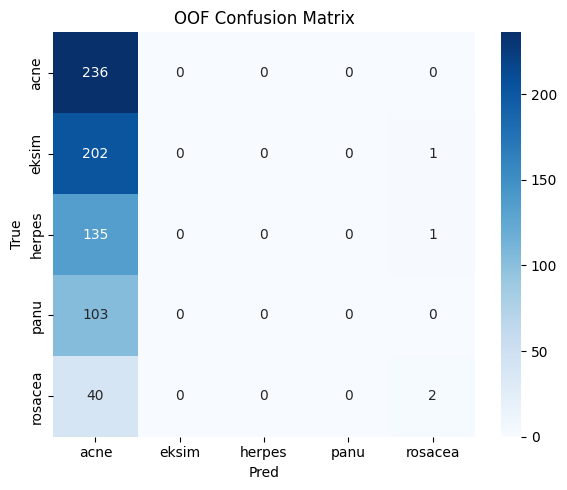

In [6]:
# =========================
# OOF analysis
# =========================
y_true = train_df['label'].values
y_pred = np.argmax(oof_proba, axis=1)

oof_macro_f1 = f1_score(y_true, y_pred, average='macro')
print('OOF Macro F1:', round(oof_macro_f1, 6))

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('OOF Confusion Matrix')
plt.xlabel('Pred')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(run_dir / 'oof_confusion_matrix.png', dpi=180)
plt.show()


In [7]:
# =========================
# Submission
# =========================
test_pred = np.argmax(test_proba, axis=1)
submission = pd.DataFrame({
    'id': test_df['id'].values,
    'disease': [idx2label[int(i)] for i in test_pred],
}).sort_values('id').reset_index(drop=True)

assert len(submission) == 180
assert submission['disease'].isin(CLASS_NAMES).all()

run_submission_path = run_dir / 'submission.csv'
platform_submission_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(run_submission_path, index=False)
submission.to_csv(platform_submission_path, index=False)

if MODE == 'local':
    local_submission_path = BASE_DIR / 'submission.csv'
    submission.to_csv(local_submission_path, index=False)

pd.DataFrame(run_logs).to_csv(run_dir / 'fold_model_metrics.csv', index=False)

summary = {
    'run_name': run_name,
    'mode': MODE,
    'device': str(device),
    'models': MODELS_TO_TRAIN,
    'n_splits': N_SPLITS,
    'epochs': EPOCHS,
    'head_epochs': HEAD_EPOCHS,
    'oof_macro_f1': float(oof_macro_f1),
}
with open(run_dir / 'run_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Run dir          :', run_dir)
print('Run submission   :', run_submission_path)
print('Platform submit  :', platform_submission_path)
if MODE == 'local':
    print('Local submit copy:', local_submission_path)

submission.head()


Run dir          : /Users/songling/Desktop/Skin Disease Classification/runs/run_95_20260220_163113
Run submission   : /Users/songling/Desktop/Skin Disease Classification/runs/run_95_20260220_163113/submission.csv
Platform submit  : /Users/songling/Desktop/Skin Disease Classification/submission.csv
Local submit copy: /Users/songling/Desktop/Skin Disease Classification/submission.csv


,id,disease
0,720,acne
1,721,acne
2,722,acne
3,723,acne
4,724,acne
